### Global Interpreter Lock (GIL)
Meccanismo utilizzato dall’interprete Python per assicurare che un solo thread alla volta possa eseguire bytecode
- Semplifica l’implementazione dell’interprete
- Rende l’object model Python implicitamente “safe” da accessi concorrenti
- Nato per realizzare thread-safe memory management, richiesto dalle librerie C utilizzate da Python

Dalla documentazione ufficiale:
> **the GIL limits the performance gains of threading when it comes to CPU-bound tasks**, as only one thread can execute Python bytecode at a time. Despite this, threads remain a useful tool for achieving concurrency in many scenarios.

| Vantaggi | Svantaggi |
|---------|----------|
| Permette di rendere facilmente multi-threaded l’interprete Python, a scapito del parallelismo | Riduce il livello di parallelismo ottenibile su macchine multi-processore |
| Dovendo gestire un solo lock, migliora le performance degli applicativi single-thread | **Impatta principalmente i task CPU-bound, in quanto è rilasciato per task I/O-bound** |
| Le librerie C non thread-safe possono essere facilmente integrate | |

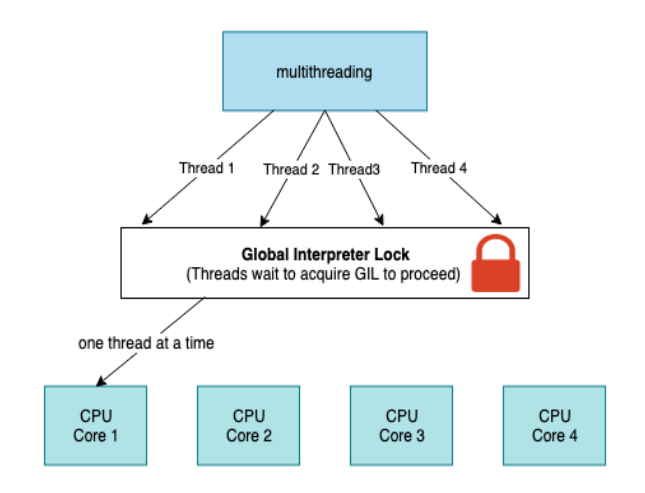


### `multiprocessing`
A tal proposito, si indroduce il modulo `multiprocessing` in Python; dalla documentazione ufficiale:

>  The multiprocessing package offers both local and remote concurrency, **effectively side-stepping the Global Interpreter Lock by using subprocesses instead of threads**. Due to this, the multiprocessing module allows the programmer to fully leverage multiple processors on a given machine.

È consigliabile usare questo modulo quando:
- si hanno a disposizione core multipli
- i task da eseguire sono principalmente CPU bound



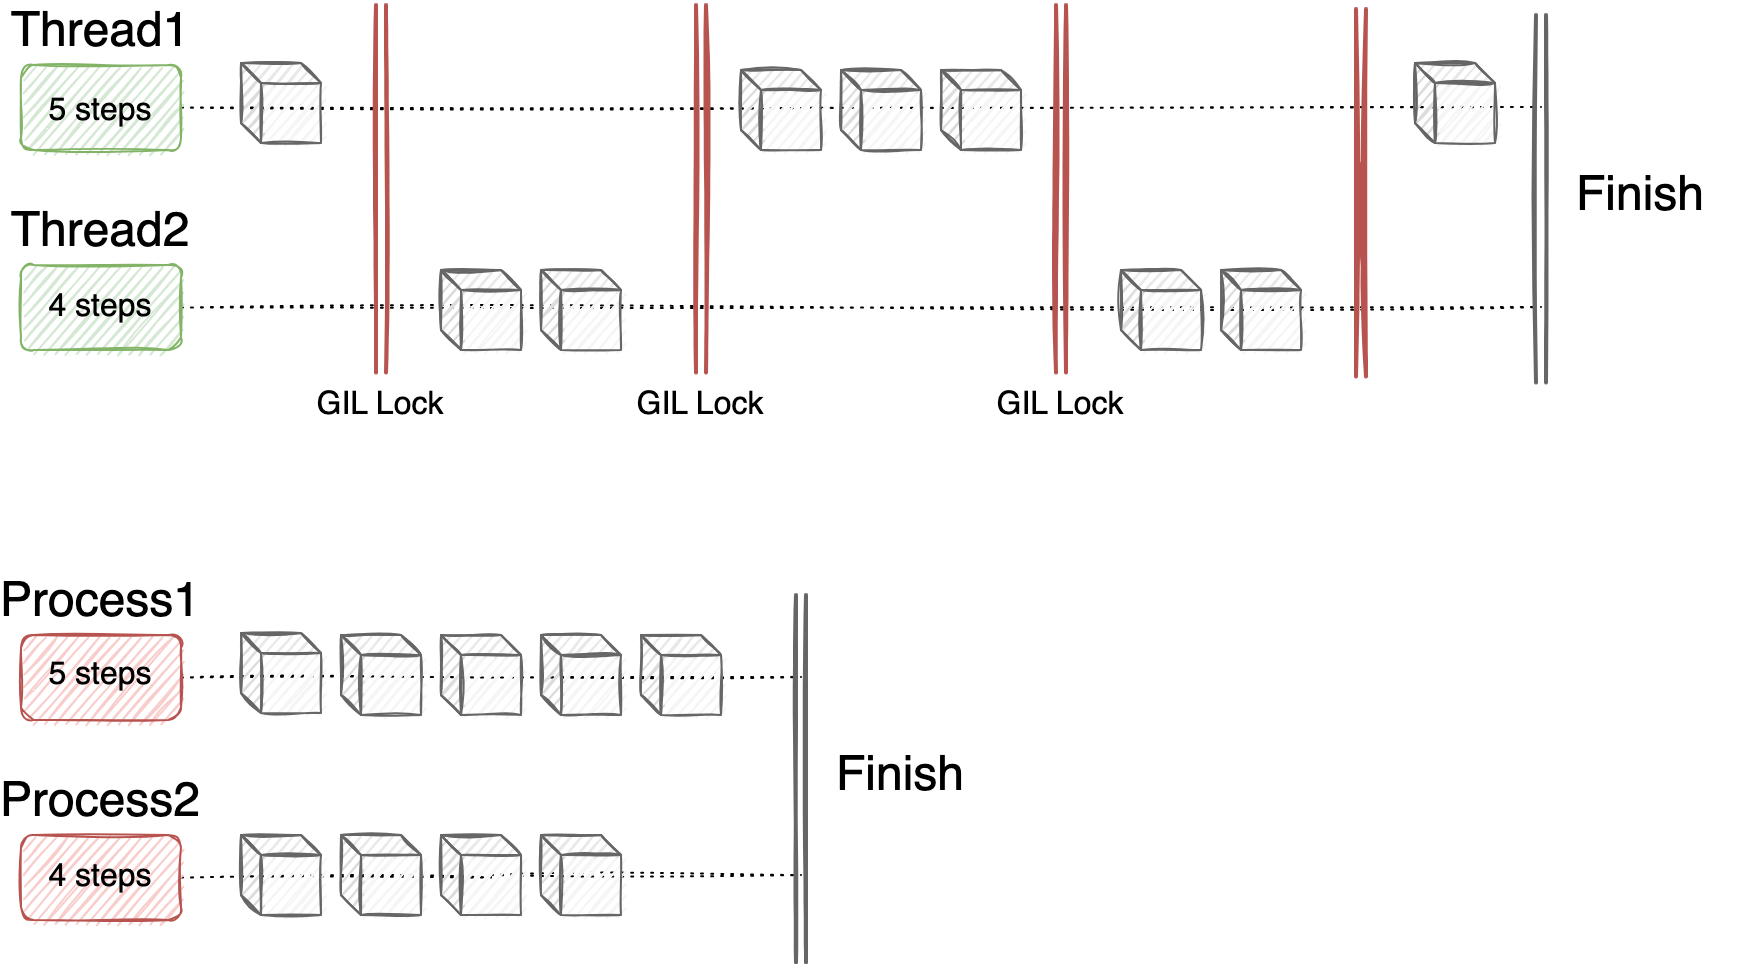

A seconda della piattaforma, il modulo multiprocessing supporta tre modi per avviare un processo attraverso il set di `start_method`. Per settare lo `start_method` è possibile utilizzare il metodo **`set_start_method(string)`** messo a disposizione nel modulo multiprocessing, passando una stringa con il modo di avvio.
I metodi di avvio sono spawn, fork, e forkserver.

| Metodo      | Disponibilità | Descrizione | Vantaggi | Svantaggi |
|------------|--------------|------------|----------|-----------|
| *spawn*      | Unix, Windows (default su Windows e macOS) | Il processo padre avvia un nuovo interpreter Python da zero. Il figlio eredita solo le risorse necessarie. | Più sicuro, ambiente pulito | Più lento |
| *fork*       | Solo Unix (default su Unix) | Il processo padre viene duplicato tramite system call `fork()`. Il figlio eredita tutte le risorse (file descriptor, lock, thread, ecc.). | Molto veloce | Unsafe con thread; possibile deadlock; eredita stato inconsistente |
| *forkserver* | Unix (se supportato) | Viene creato un processo server. Il padre chiede al server di creare nuovi processi tramite fork. | Più sicuro di fork; evita eredità non necessaria | Più complesso; richiede supporto specifico |

### `multiprocess`
Dalla documentazione ufficiale:

> `multiprocess` is a fork of `multiprocessing`. `multiprocess` extends `multiprocessing` to provide enhanced serialization, using `dill`. `multiprocess` leverages `multiprocessing` to support the spawning of processes using the API of the Python standard library’s `threading` module.
>
> **Major Features**
>
> `multiprocess` enables.
> - objects to be transferred between processes using pipes or multi-producer/multi-consumer queues
> - objects to be shared between processes using a server process or (for simple data) shared memory
>
> `multiprocess` provides:
> - equivalents of all the synchronization primitives in threading
> - a Pool class to facilitate submitting tasks to worker processes
> - enhanced serialization, using dill

#### La classe `Process`
Un oggetto della classe `Process` rappresenta una attività da eseguire in un processo separato. La classe `Process` possiede metodi equivalenti a quelli della classe `threading.Thread`.

In [ ]:
import multiprocess as mp
help(mp.Process.__init__)
help(mp.Process.start)
help(mp.Process.run)
help(mp.Process.join)
help(mp.Process.is_alive)

Come per la classe `Thread`, anche la classe `Process` permette la creazione di un processo in vari modi:
1. usando callable object
2. estendendo la classe `Process` stessa

In [ ]:
# [1]
import sys
import multiprocess as mp
from loguru import logger

logger.remove()
logger.add(sink=sys.stderr,format="{level} {process.name}({process.id}) {message}")

def func():
    logger.info('Running')
    return

if __name__ == '__main__':
    # creating process
    p = mp.Process(target = func)
    # starting process
    p.start()
    # wait until the process finishes
    p.join()

In [ ]:
import multiprocess as mp
from loguru import logger

logger.remove()
logger.add(sink=sys.stderr,format="{level} {process.name}({process.id}) {message}")

class MyProcess(mp.Process):
    def run(self):
        logger.info('Running')
        return


if __name__ == '__main__':
    # creating process
    p = MyProcess()
    # starting process
    p.start()
    # wait until the process finishes
    p.join()

Il modulo multiprocess contiene primitive di sincronizzazione equivalenti a quelle fornite nel modulo threading. Pertanto anche con i processi è possibile utilizzare **Lock, RLock, Semaphore, Condition ed Event**.

In [ ]:
import multiprocess as mp
help(mp.Lock)
help(mp.RLock)
help(mp.Semaphore)
help(mp.Condition)
help(mp.Event)

#### Pipe e Queue
Quando sono utilizzati processi multipli, è spesso necessario prevedere dei canali di comunicazione tra gli stessi che permettano di evitare l’uso di primitive di sincronizzazione.

Il modulo `multiprocessing` supporta due canali di comunicazione tra processi:
- **Pipe**, che consente la connessione fra 2 processi - caratterizzata da una coppia di Connection objects, che rappresentano gli endpoint della pipe
- **Queue**, che supporta (di fatto implementa) il problema produttori-consumatori multipli - è una process shared queue, implementata attraverso una pipe e locks/semaphores

> Sia Pipe che Queue sono thread/process-safe

In [ ]:
import multiprocessing as mp
from multiprocessing.connection import Connection 
help(mp.Pipe) # <-- parametro duplex
"""
If duplex is True (the default) then the pipe is bidirectional. If duplex is False then 
the pipe is unidirectional: conn1 can only be used for receiving messages and conn2 can 
only be used for sending messages.
"""
help(Connection.send)
help(Connection.recv) # <-- Il metodo è bloccante se non ci sono oggetti da ricevere

In [ ]:
from multiprocess import Process, Pipe
import sys
from loguru import logger
import os

logger.remove()
logger.add(sink=sys.stderr, format="{level} {process.name}({process.id}) {message}")

def parentData(parent):
    parent.send(['Hello'])
    logger.info("Sent Hello")
    parent.close()
def childData(child):
    child.send(['Bye'])
    logger.info("Sent Bye")
    child.close()

if __name__ == '__main__':
    parent_conn, child_conn = Pipe()
    p1 = Process(target=parentData, args=(parent_conn,))
    p1.start()
    p2 = Process(target=childData, args=(child_conn,))
    p2.start()
    print(parent_conn.recv())
    print(child_conn.recv())
    p1.join()
    p2.join()

**Nota su `process.name` in Jupyter Notebook**

Quando si usa `multiprocessing` / `multiprocess` dentro un **Jupyter Notebook**, il campo `process.name` nei log può risultare fuorviante: anche processi distinti possono comparire come `MainProcess`.

Questo succede perché il notebook non viene eseguito come un normale script `.py`, ma all’interno di un **kernel IPython/Jupyter**, che modifica il contesto di esecuzione dei processi figli.

Di conseguenza:

- il nome del processo non è sempre affidabile per distinguere i processi in notebook;
- per verificare che si tratti davvero di processi distinti conviene usare il **PID**.

Nei normali script Python eseguiti da terminale, invece, process.name è generalmente più chiaro (MainProcess, Process-1, Process-2, ...).

In [ ]:
from multiprocess.queues import Queue
help(Queue.__init__)
help(Queue.qsize)
help(Queue.empty)
help(Queue.full)
help(Queue.put)
help(Queue.put_nowait) # <-- Equivalente a put(item, block=False)
help(Queue.get) # <-- Rimuove e ++ritorna++ un elemento dalla coda
help(Queue.get_nowait) # <-- Equivalente a get(block=False)

In [ ]:
from multiprocess import Process, Queue
from loguru import logger
import sys
import random

logger.remove()
logger.add(sink=sys.stderr, format="{level} {process.name}({process.id}) {message}")

def f(q):
    x = random.randint(1,100)
    logger.info("Put: {}", x)
    q.put(x)

if __name__ == '__main__':
    q = Queue()
    processes = [Process(target=f, args=(q,)) for _ in range(2)]
    
    for p in processes:
        p.start()
    
    for p in processes:
        p.join()

    val = q.get()
    logger.info("Got: {}", val)
    logger.info("Queue is: {} empty", "" if q.empty() else "not")
    logger.info("Queue size is: {}", q.qsize())



#### Shared Memory
Le **shared memory** sono uno degli strumenti offerti dal modulo `multiprocessing` per la condivisione di dati tra processi. In Python una shared memory è rappresentata da oggetti di tipo Value o Array, che sono *process-safe* e *thread-safe*.

In [ ]:
import multiprocessing as mp
help(mp.Value)
help(mp.Array)

Dalla documentazione ufficiale di `Value`:

> `typecode_or_type` determines the type of the returned object: it is either a ctypes type or a one character typecode of the kind used by the [array](https://docs.python.org/3/library/array.html#module-array) module.
> 
> If `lock` is True (the default) then a new recursive lock object is created to synchronize access to the value. If `lock` is a **Lock** or **RLock** object then that will be used to synchronize access to the value. If `lock` is False then access to the returned object will not be automatically protected by a lock, so it will not necessarily be “process-safe”.

Dalla documentazione ufficiale di `Array`:

> `typecode_or_type` determines the type of the elements of the returned array: it is either a ctypes type or a one character typecode of the kind used by the [array](https://docs.python.org/3/library/array.html#module-array) module with the exception of `'w'`, which is not supported. In addition, the `'c'` typecode is an alias for `ctypes.c_char`.
> 
> If `size_or_initializer` is an integer, then it determines the length of the array, and **the array will be initially zeroed**. Otherwise, `size_or_initializer` is a sequence which is used to initialize the array and whose length determines the length of the array.
>
> If `lock` is True (the default) then a new lock object is created to synchronize access to the value. If `lock` is a Lock or RLock object then that will be used to synchronize access to the value. If `lock` is False then access to the returned object will not be automatically protected by a lock, so it will not necessarily be “process-safe”.